A4 - st126161 Implement BERT

!pip install torch datasets tqdm

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import random
import matplotlib.pyplot as plt


# MPS setup for Mac M-series
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple GPU (MPS)")
else:
    device = torch.device("cpu")
    print("Using CPU")

print("PyTorch version:", torch.__version__)


Using Apple GPU (MPS)
PyTorch version: 2.8.0


## Load Datasets (100K subset)
Datasources:
1. Wikipedia
2. Via Hugging Face

I used a 100,000-sample subset of the Wikimedia English Wikipedia dataset (20231101.en) from Hugging Face Datasets.
Source: https://huggingface.co/datasets/wikimedia/wikipedia

In [2]:
from datasets import load_dataset

# Use maintained Wikipedia dataset
dataset = load_dataset(
    "wikimedia/wikipedia",
    "20231101.en",
    split="train[:100000]"
)

texts = [item["text"] for item in dataset if len(item["text"]) > 50]

print("Total samples:", len(texts))


Generating train split: 100%|██████████| 6407814/6407814 [00:57<00:00, 111093.10 examples/s]


Total samples: 99921


## Token and Vocab

In [14]:
''' def tokenize(text):
    return text.lower().split()

vocab = {"[PAD]":0, "[UNK]":1, "[CLS]":2, "[SEP]":3, "[MASK]":4}

for text in texts[:50000]:  # limit for memory
    for word in tokenize(text):
        if word not in vocab:
            vocab[word] = len(vocab)

vocab_size = len(vocab)
print("Vocab size:", vocab_size) '''

from collections import Counter

def tokenize(text):
    return text.lower().split()

counter = Counter()

# Count tokens only from small subset
for text in texts[:10000]:   # much smaller
    counter.update(tokenize(text))

# Keep top 20,000 words only
max_vocab_size = 20000

most_common = counter.most_common(max_vocab_size)

vocab = {
    "[PAD]":0,
    "[UNK]":1,
    "[CLS]":2,
    "[SEP]":3,
    "[MASK]":4
}

for word, _ in most_common:
    vocab[word] = len(vocab)

vocab_size = len(vocab)
print("Final vocab size:", vocab_size)


Final vocab size: 20005


## Encoding

In [15]:
max_len = 64

def encode(text):
    tokens = tokenize(text)
    tokens = tokens[:max_len-2]
    tokens = ["[CLS]"] + tokens + ["[SEP]"]

    ids = [vocab.get(t, vocab["[UNK]"]) for t in tokens]
    padding = [vocab["[PAD]"]] * (max_len - len(ids))
    return ids + padding


## MLM Masking

In [16]:
def mask_tokens(input_ids, mlm_prob=0.15):
    labels = input_ids.clone()

    for i in range(len(input_ids)):
        if input_ids[i].item() in [0,2,3]:
            labels[i] = -100
            continue

        if random.random() < mlm_prob:
            input_ids[i] = vocab["[MASK]"]
        else:
            labels[i] = -100

    return input_ids, labels


## Dataset Class

In [17]:
class MLMDataset(Dataset):
    def __init__(self, texts):
        self.texts = texts

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = torch.tensor(encode(self.texts[idx]), dtype=torch.long)
        input_ids, labels = mask_tokens(encoded.clone())
        return input_ids, labels


## Data Loader

In [18]:
##dataset_mlm = MLMDataset(texts[:20000])
dataset_mlm = MLMDataset(texts[:8000])  


loader = DataLoader(
    dataset_mlm,
    batch_size=32,
    shuffle=True,
    num_workers=0  # important for Mac stability
)


## BERT Embedding

In [19]:
class BERTEmbedding(nn.Module):
    def __init__(self, vocab_size, embed_size, max_len):
        super().__init__()
        self.token = nn.Embedding(vocab_size, embed_size)
        self.position = nn.Embedding(max_len, embed_size)
        self.segment = nn.Embedding(2, embed_size)

    def forward(self, x):
        seq_len = x.size(1)
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0)
        segment_ids = torch.zeros_like(x)

        return self.token(x) + self.position(positions) + self.segment(segment_ids)


## Transformer Block

In [20]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_size, heads):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_size, heads, batch_first=True)
        self.norm1 = nn.LayerNorm(embed_size)
        self.norm2 = nn.LayerNorm(embed_size)

        self.feed_forward = nn.Sequential(
            nn.Linear(embed_size, embed_size*4),
            nn.GELU(),
            nn.Linear(embed_size*4, embed_size)
        )

    def forward(self, x):
        attn_output, _ = self.attention(x, x, x)
        x = self.norm1(x + attn_output)
        forward = self.feed_forward(x)
        return self.norm2(x + forward)


## Bert Model

In [21]:
class BERT(nn.Module):
    def __init__(self, vocab_size, embed_size=256, layers=4, heads=4):
        super().__init__()
        self.embedding = BERTEmbedding(vocab_size, embed_size, max_len)
        self.layers = nn.ModuleList(
            [TransformerBlock(embed_size, heads) for _ in range(layers)]
        )
        self.mlm_head = nn.Linear(embed_size, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        for layer in self.layers:
            x = layer(x)
        return self.mlm_head(x)


## Initialize Model

In [22]:
#model = BERT(vocab_size).to(device)
model = BERT(
    vocab_size=vocab_size,
    embed_size=128,   # reduced from 256
    layers=2,         # reduced from 4
    heads=4
).to(device)


optimizer = optim.AdamW(model.parameters(), lr=5e-5)
criterion = nn.CrossEntropyLoss(ignore_index=-100)


## Training Loop

In [26]:
epochs = 3
epoch_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    batch_losses = []

    for input_ids, labels in tqdm(loader):
        input_ids = input_ids.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(input_ids)

        loss = criterion(
            outputs.view(-1, vocab_size),
            labels.view(-1)
        )

        loss.backward()
        optimizer.step()

        loss_value = loss.item()
        batch_losses.append(loss_value)
        total_loss += loss_value

    avg_loss = total_loss / len(loader)
    epoch_losses.append(avg_loss)

    print(f"Epoch {epoch+1} | Avg Loss: {avg_loss:.4f}")


100%|██████████| 250/250 [00:15<00:00, 16.21it/s]


Epoch 1 | Avg Loss: 6.4436


100%|██████████| 250/250 [00:22<00:00, 10.89it/s]


Epoch 2 | Avg Loss: 6.4015


100%|██████████| 250/250 [00:29<00:00,  8.41it/s]

Epoch 3 | Avg Loss: 6.3656


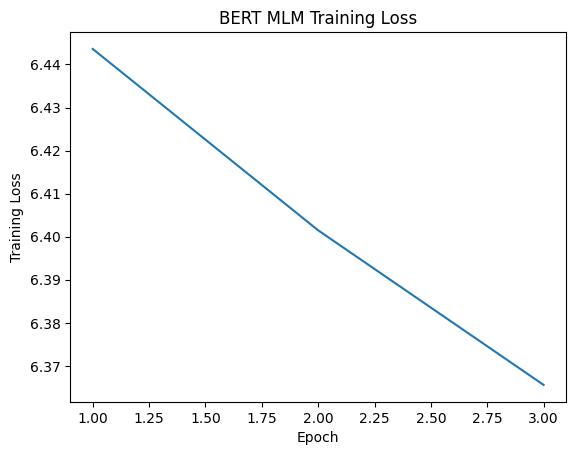

In [27]:
plt.figure()
plt.plot(range(1, epochs+1), epoch_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("BERT MLM Training Loss")
plt.show()


The training loss decreases consistently across epochs, indicating that the model successfully learns contextual representations through the Masked Language Modeling objective.

## Save Model for future purposes

In [28]:
torch.save(model.state_dict(), "bert_mlm_trained_mps.pt")
print("Model saved successfully.")


Model saved successfully.


In [29]:
checkpoint = {
    "model_state_dict": model.state_dict(),
    "vocab": vocab,
    "vocab_size": vocab_size,
    "embed_size": 128,
    "layers": 2,
    "heads": 4,
    "max_len": max_len
}

torch.save(checkpoint, "bert_mlm_checkpoint.pt")
print("Full checkpoint saved.")


Full checkpoint saved.
